<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/9_Recurrent_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Set up

import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
# Tiny dataset

text = "hello world " * 200

chars = sorted(set(text))
print("Vocab: ", chars)
vocab_size = len(chars)
print("Vocab size: ", vocab_size)

stoi = {ch:i for i,ch in enumerate(chars)} # Create an dict to map from char to index
itos = {i:ch for ch,i in stoi.items()} # Create an dict to map from index to char
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)

Vocab:  [' ', 'd', 'e', 'h', 'l', 'o', 'r', 'w']
Vocab size:  8


In [3]:
# Create batch sequence

def get_batch(data, seq_len=20, batch_size=32):
    ix = torch.randint(len(data)-seq_len-1, (batch_size,))
    x = torch.stack([data[i:i+seq_len] for i in ix])
    y = torch.stack([data[i+1:i+seq_len+1] for i in ix])
    return x.to(device), y.to(device)

In [4]:
# RNN model

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        x = self.embed(x)
        out, h = self.rnn(x, h)
        out = self.fc(out)
        return out, h

model = SimpleRNN(vocab_size, 128).to(device)

0 2.0610880851745605
100 0.04062025249004364
200 0.027457863092422485
300 0.04020562022924423
400 0.03212735801935196
500 0.019227998331189156
600 0.028824660927057266
700 0.02513924241065979
800 0.02877057157456875
900 0.023180659860372543


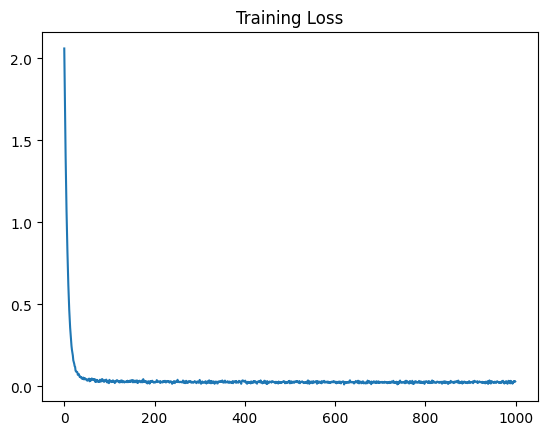

In [5]:
# Train + Visualize loss

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []

for step in range(1000):
    x, y = get_batch(data)

    logits, _ = model(x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

    optimizer.zero_grad()
    loss.backward()

    # gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    losses.append(loss.item())

    if step % 100 == 0:
        print(step, loss.item())

plt.plot(losses)
plt.title("Training Loss")
plt.show()


In [6]:
# Generate text

def generate(model, start="h", length=100):
    model.eval()
    x = torch.tensor([[stoi[start]]], device=device)
    h = None
    result = start

    for _ in range(length):
        logits, h = model(x, h)
        probs = F.softmax(logits[:, -1, :], dim=-1)
        idx = torch.multinomial(probs, num_samples=1)

        ch = itos[idx.item()]
        result += ch

        x = idx

    return result

print(generate(model, "h", 200))


hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello world hello wor


https://joshvarty.github.io/VisualizingRNNs/